In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, jaccard_score

In [2]:
bewerkte_data_dir = '/home/laura/Scriptie/bewerkte_data/SegTHRawS'
thresholds = np.linspace(0.05, 0.95, 19)

def plot_model_performance(y_true, y_probs, model_name):
    precisions, recalls, mious = [], [], []
    
    for t in thresholds:
        preds = (y_probs >= t).astype(int)
        precisions.append(precision_score(y_true, preds, zero_division=0))
        recalls.append(recall_score(y_true, preds, zero_division=0))
        mious.append(jaccard_score(y_true, preds, zero_division=0))

    plt.figure(figsize=(10, 6))
    plt.plot(thresholds, precisions, label='Precision (less false positives)', marker='s', color='tab:blue')
    plt.plot(thresholds, recalls, label='Recall', marker='o', color='tab:orange')
    plt.plot(thresholds, mious, label='mIoU', linewidth=3, color='black')
    plt.axvline(0.5, color='gray', linestyle='--', label='Standaard Drempel (0.5)')
    
    plt.title(f'Impact on certainty threshold - {model_name}')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

y_true_seg = np.load(os.path.join(bewerkte_data_dir, 'y_test_masks.npy')).flatten()

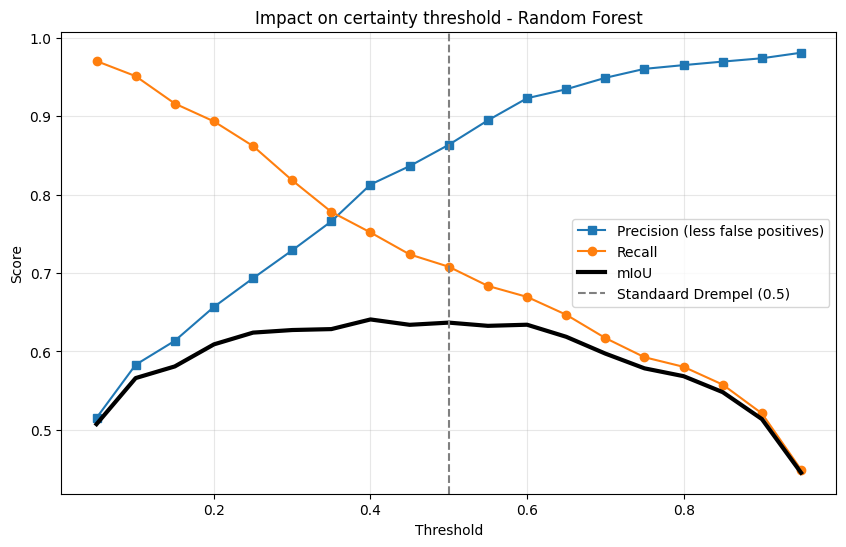

In [3]:
# ----------------------------------------------------------
# ---- Random Forest Threshold Analysis (More Detailed) ----
# ----------------------------------------------------------

try:
    probs_rf = np.load(os.path.join(bewerkte_data_dir, 'y_pred_probs_fire_rf.npy')).flatten()
    plot_model_performance(y_true_seg, probs_rf, "Random Forest")
except FileNotFoundError:
    print("Data not found")

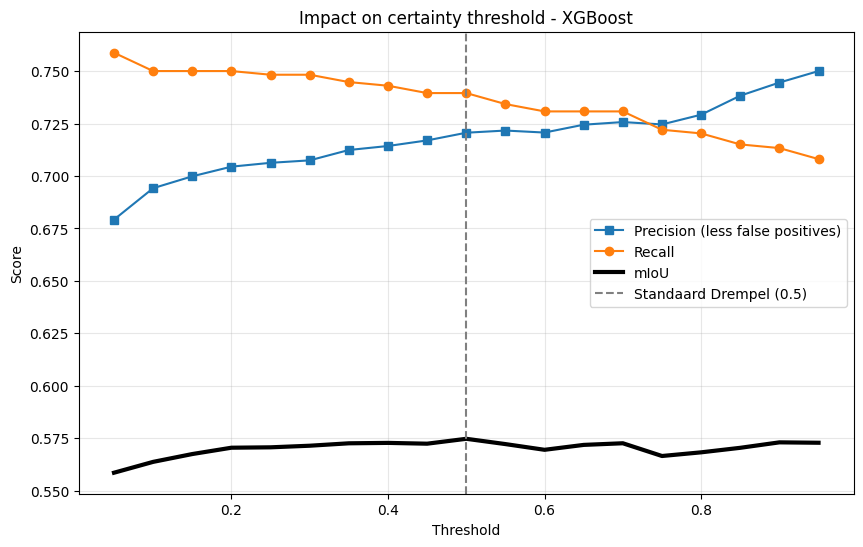

In [4]:
# ----------------------------------------------------
# ---- XGBoost Threshold Analysis (More Detailed) ----
# ----------------------------------------------------

try:
    probs_xgb = np.load(os.path.join(bewerkte_data_dir, 'y_pred_probs_fire_xgb.npy')).flatten()
    plot_model_performance(y_true_seg, probs_xgb, "XGBoost")
except FileNotFoundError:
    print("Data not found")

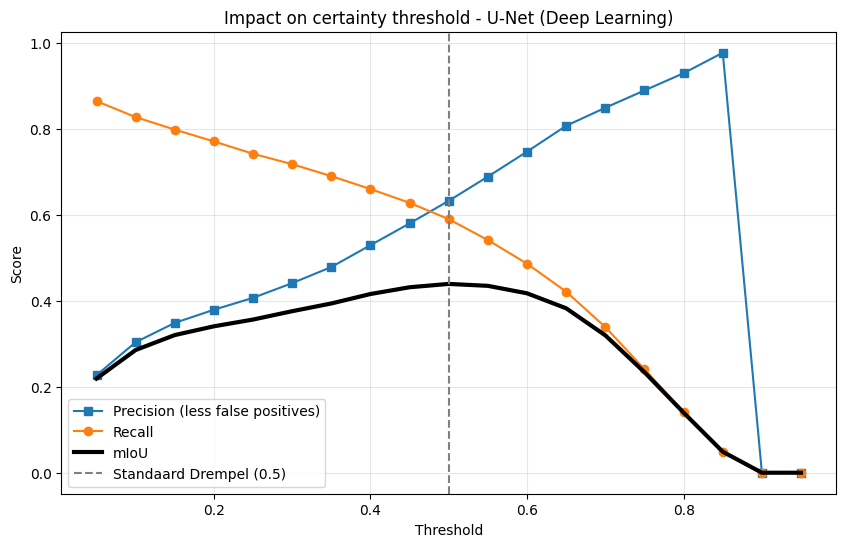

In [5]:
# --------------------------------------------------
# ---- U-Net Threshold Analysis (More Detailed) ----
# --------------------------------------------------
try:
    y_true_unet = np.load(os.path.join(bewerkte_data_dir, 'y_test_masks_unet.npy')).flatten()
    
    probs_unet = np.load(os.path.join(bewerkte_data_dir, 'y_pred_probs_fire_unet.npy')).flatten()

    plot_model_performance(y_true_unet, probs_unet, "U-Net (Deep Learning)")

except Exception as e:
    print(f"Error: {e}")

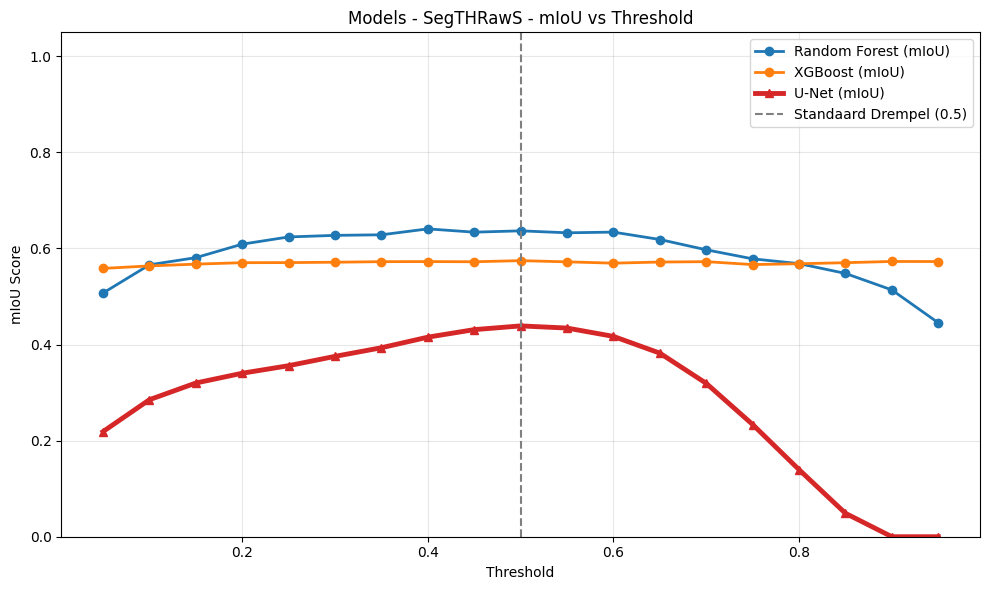

In [6]:
bewerkte_data_dir = '/home/laura/Scriptie/bewerkte_data/SegTHRawS'
thresholds = np.linspace(0.05, 0.95, 19)

plt.figure(figsize=(10, 6))
models = {
    'Random Forest': 'y_pred_probs_fire_rf.npy',
    'XGBoost': 'y_pred_probs_fire_xgb.npy',
    'U-Net': 'y_pred_probs_fire_unet.npy'
}

for name, file in models.items():
    pad = os.path.join(bewerkte_data_dir, file)
    if os.path.exists(pad):
        probs = np.load(pad).flatten()
    
        if name == 'U-Net':
            y_true_correct = np.load(os.path.join(bewerkte_data_dir, 'y_test_masks_unet.npy')).flatten()
        else:
            y_true_correct = np.load(os.path.join(bewerkte_data_dir, 'y_test_masks.npy')).flatten()

        mious = [jaccard_score(y_true_correct, (probs >= t).astype(int), zero_division=0) for t in thresholds]
       
        if name == 'U-Net':
            plt.plot(thresholds, mious, label=f'{name} (mIoU)', linewidth=3.5, marker='^', color='tab:red')
        else:
            plt.plot(thresholds, mious, label=f'{name} (mIoU)', linewidth=2.0, marker='o')

plt.axvline(0.5, color='gray', linestyle='--', label='Standaard Drempel (0.5)')
plt.title('Models - SegTHRawS - mIoU vs Threshold')
plt.xlabel('Threshold')
plt.ylabel('mIoU Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0.0, 1.05) 
plt.tight_layout()
plt.show()


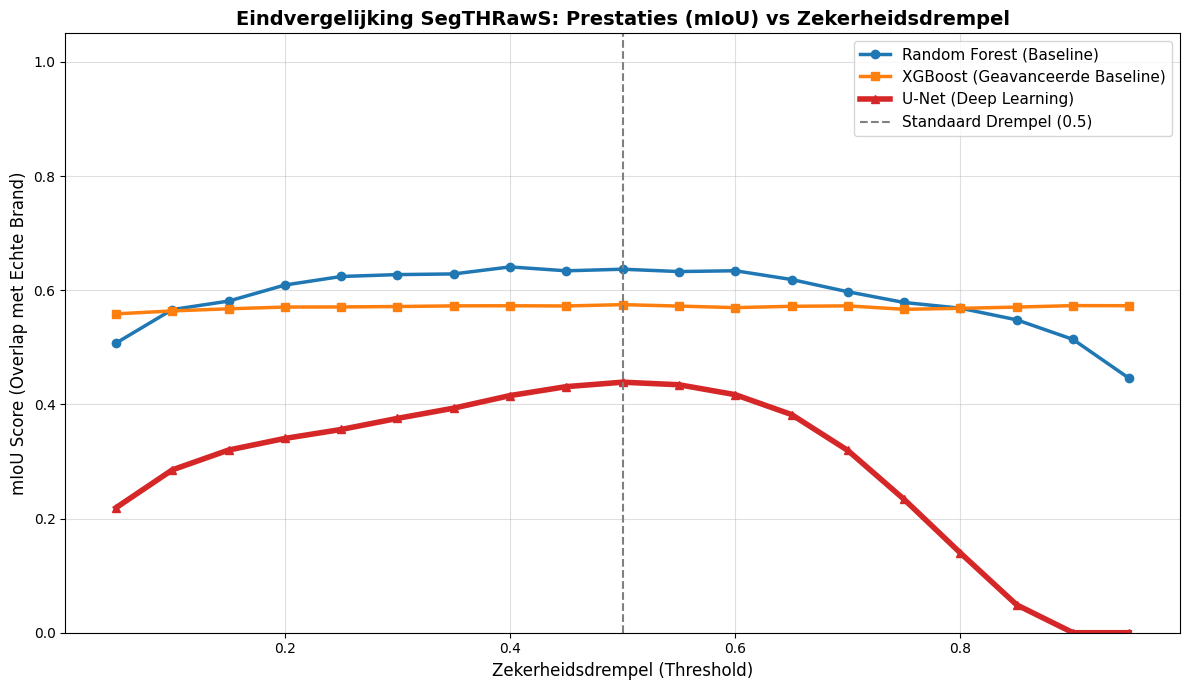

In [7]:
thresholds = np.linspace(0.05, 0.95, 19)

plt.figure(figsize=(12, 7))

try:
    y_true_rf = np.load(os.path.join(bewerkte_data_dir, 'y_test_masks.npy')).flatten()
    probs_rf = np.load(os.path.join(bewerkte_data_dir, 'y_pred_probs_fire_rf.npy')).flatten()
    mious_rf = [jaccard_score(y_true_rf, (probs_rf >= t).astype(int), zero_division=0) for t in thresholds]
    plt.plot(thresholds, mious_rf, label='Random Forest (Baseline)', linewidth=2.5, marker='o', color='tab:blue')
except Exception as e: 
    print(f"Error: {e}")

try:
    y_true_xgb = np.load(os.path.join(bewerkte_data_dir, 'y_test_masks.npy')).flatten() 
    probs_xgb = np.load(os.path.join(bewerkte_data_dir, 'y_pred_probs_fire_xgb.npy')).flatten()
    mious_xgb = [jaccard_score(y_true_xgb, (probs_xgb >= t).astype(int), zero_division=0) for t in thresholds]
    plt.plot(thresholds, mious_xgb, label='XGBoost (Geavanceerde Baseline)', linewidth=2.5, marker='s', color='tab:orange')
except Exception as e: 
    print(f"Error: {e}")

try:
    y_true_unet = np.load(os.path.join(bewerkte_data_dir, 'y_test_masks_unet.npy')).flatten()
    probs_unet = np.load(os.path.join(bewerkte_data_dir, 'y_pred_probs_fire_unet.npy')).flatten()
    mious_unet = [jaccard_score(y_true_unet, (probs_unet >= t).astype(int), zero_division=0) for t in thresholds]
    plt.plot(thresholds, mious_unet, label='U-Net (Deep Learning)', linewidth=4, marker='^', color='tab:red')
except Exception as e: 
    print(f"Error: {e}")

plt.axvline(0.5, color='gray', linestyle='--', label='Standaard Drempel (0.5)')
plt.title('Eindvergelijking SegTHRawS: Prestaties (mIoU) vs Zekerheidsdrempel', fontsize=14, fontweight='bold')
plt.xlabel('Zekerheidsdrempel (Threshold)', fontsize=12)
plt.ylabel('mIoU Score (Overlap met Echte Brand)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.4)

plt.ylim(0.0, 1.05) 
plt.tight_layout()
plt.show()